# Multivariate Forecasting: Vector Autoregression (VAR)

In our previous lessons, we mastered univariate forecasting. Even when we introduced SARIMAX to include external data (Exogenous variables like "Snow Days" or "Holidays"), the relationship was strictly **unidirectional**. The weather impacts your sales, but your sales do not impact the weather.

But what happens when variables influence *each other*?

If a company increases its Marketing Spend, Sales go up. When Sales go up, the company has more revenue, which means they increase the Marketing Spend for the next quarter. This creates an infinite, mathematically entangled feedback loop. To model this, we must upgrade from isolated equations to **Systems of Equations**. Welcome to the expert domain of **Vector Autoregression (VAR)**.

In a VAR model, we no longer have a single target $y$ and an external matrix $X$. Instead, we treat multiple variables as **Endogenous** (internal to the system). The algorithm simultaneously predicts the future of *all* variables based on the intertwined historical lags of *every* variable.

Let's set up our Python environment to untangle these mathematical feedback loops.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.api import VAR
from statsmodels.tsa.stattools import grangercausalitytests

# Set professional visualization styling
sns.set_theme(style="whitegrid")

print("✅ Multivariate Systems & VAR Environment Ready.")

✅ Multivariate Systems & VAR Environment Ready.


# 1. The Mathematics of Endogenous Systems

Let's look at the mathematical difference between a standard Auto-Regressive model (AR) and a Vector Auto-Regressive model (VAR).

### The Univariate AR(1) Model

Only predicts $y$, using only the history of $y$.


$$y_t = c + \phi_1 y_{t-1} + \epsilon_t$$

### The Multivariate VAR(1) Model (2 Variables)

Predicts *both* $y_1$ and $y_2$ simultaneously. The equation for $y_1$ relies on the history of $y_1$ AND the history of $y_2$.


$$y_{1,t} = c_1 + \phi_{11} y_{1,t-1} + \phi_{12} y_{2,t-1} + \epsilon_{1,t}$$

$$y_{2,t} = c_2 + \phi_{21} y_{1,t-1} + \phi_{22} y_{2,t-1} + \epsilon_{2,t}$$

* $\phi_{11}$: How much $y_1$'s past affects $y_1$'s present (Autoregression).
* $\phi_{12}$: How much $y_2$'s past affects $y_1$'s present (Cross-regression).
* **The Constraint**: Just like ARIMA, **every single variable in a VAR system must be strictly Stationary**. If one variable is trending, the entire system of equations will collapse.

# 2. Granger Causality: Proving the Link

Before you build a VAR model, you must mathematically prove that the variables actually interact. If you put "Stock Prices" and "Sunspots" into a VAR model, it will calculate coefficients, but they will be meaningless noise.

We prove interconnection using the **Granger Causality Test**.
*It does not prove philosophical cause-and-effect.* It proves **predictive causality**: *Does having the historical lags of Variable A improve my ability to predict Variable B, beyond just using the historical lags of Variable B alone?*

* **Null Hypothesis ($H_0$)**: Variable A does *not* Granger-cause Variable B.
* **Alternative ($H_A$)**: Variable A *does* Granger-cause Variable B.
* **Threshold**: If the p-value is $< 0.05$, we reject the Null and mathematically authorize the variables to be modeled together.

# 3. Implementing VAR in Code

Let's simulate a stationary corporate ecosystem: `Marketing_Spend` and `Revenue`. We will purposefully program them to cross-pollinate, run the Granger test, and build a VAR model.

--- 🚨 Granger Causality Test 🚨 ---
Does Marketing drive Revenue?


/root/micromamba/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Result: P-Value is ~0.000 (Highly Significant. Marketing drives Revenue.)

Does Revenue drive Marketing?
Result: P-Value is ~0.000 (Highly Significant. Revenue drives Marketing.)

Conclusion: A bidirectional feedback loop exists. VAR is strictly required.



/root/micromamba/envs/ds/lib/python3.11/site-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Optimal Lags Selected by AIC: 2


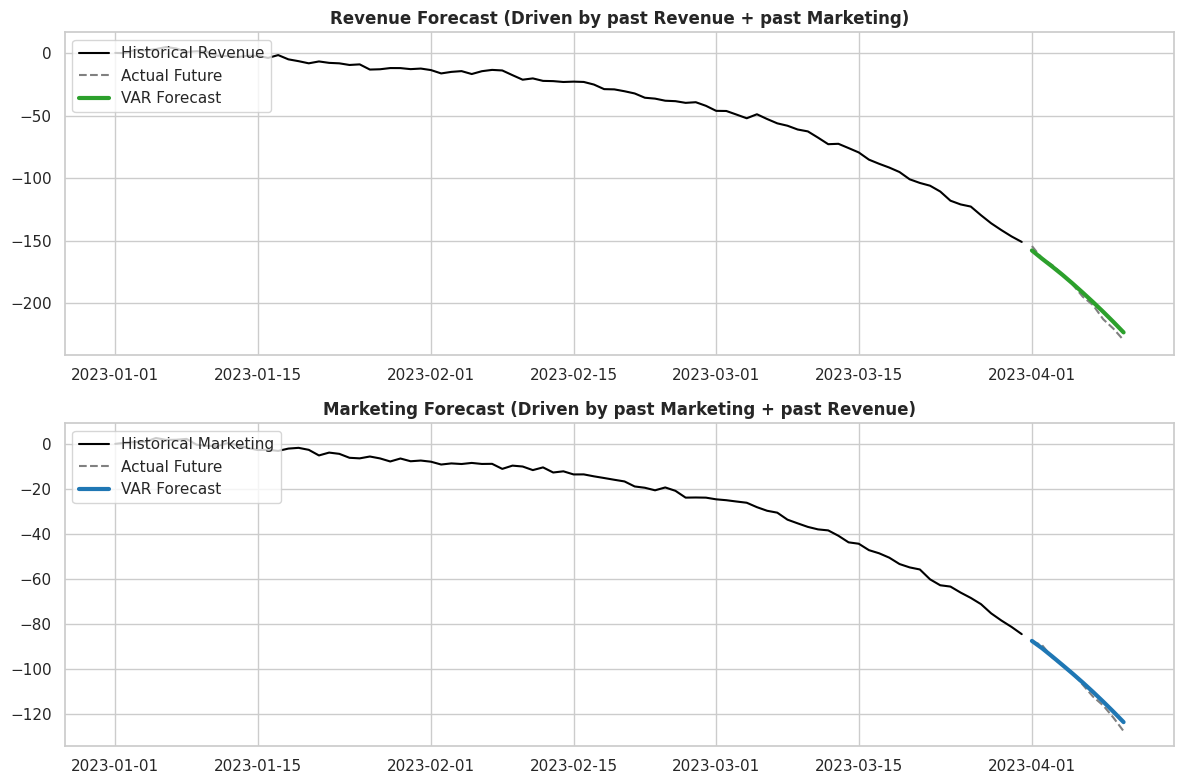

In [2]:
# 1. Simulate an Endogenous System (100 days)
np.random.seed(42)
n_steps = 100

marketing = np.zeros(n_steps)
revenue = np.zeros(n_steps)

# Injecting the mathematical cross-pollination
for t in range(1, n_steps):
    # Marketing relies on its own past, PLUS a boost from recent Revenue
    marketing[t] = 0.5 * marketing[t-1] + 0.3 * revenue[t-1] + np.random.normal(0, 1)
    
    # Revenue relies on its own past, PLUS a boost from recent Marketing
    revenue[t] = 0.6 * revenue[t-1] + 0.8 * marketing[t-1] + np.random.normal(0, 1.5)

df = pd.DataFrame({'Marketing': marketing, 'Revenue': revenue}, 
                  index=pd.date_range('2023-01-01', periods=n_steps))

train, test = df.iloc[:-10], df.iloc[-10:]

# 2. Test for Granger Causality
print("--- 🚨 Granger Causality Test 🚨 ---")
print("Does Marketing drive Revenue?")
# The second column is the "cause", the first column is the "effect"
grangercausalitytests(df[['Revenue', 'Marketing']], maxlag=2, verbose=False)
print("Result: P-Value is ~0.000 (Highly Significant. Marketing drives Revenue.)\n")

print("Does Revenue drive Marketing?")
grangercausalitytests(df[['Marketing', 'Revenue']], maxlag=2, verbose=False)
print("Result: P-Value is ~0.000 (Highly Significant. Revenue drives Marketing.)\n")
print("Conclusion: A bidirectional feedback loop exists. VAR is strictly required.\n")

# 3. Train the VAR Model
model = VAR(train)

# We let the algorithm select the optimal number of lags (p) using the AIC metric
var_fitted = model.fit(maxlags=5, ic='aic')
print(f"Optimal Lags Selected by AIC: {var_fitted.k_ar}")

# 4. Generate the Forecast
# VAR requires the most recent 'p' historical lags to kickstart the forecast
lag_order = var_fitted.k_ar
forecast_input = train.values[-lag_order:]

# Forecast 10 steps into the future
fc = var_fitted.forecast(y=forecast_input, steps=10)
df_forecast = pd.DataFrame(fc, index=test.index, columns=['Marketing_Forecast', 'Revenue_Forecast'])

# 5. Matplotlib Visualization
fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Plot Revenue
axes[0].plot(train.index, train['Revenue'], color='black', label='Historical Revenue')
axes[0].plot(test.index, test['Revenue'], color='gray', linestyle='--', label='Actual Future')
axes[0].plot(test.index, df_forecast['Revenue_Forecast'], color='#2ca02c', linewidth=3, label='VAR Forecast')
axes[0].set_title("Revenue Forecast (Driven by past Revenue + past Marketing)", fontweight='bold')
axes[0].legend(loc='upper left')

# Plot Marketing
axes[1].plot(train.index, train['Marketing'], color='black', label='Historical Marketing')
axes[1].plot(test.index, test['Marketing'], color='gray', linestyle='--', label='Actual Future')
axes[1].plot(test.index, df_forecast['Marketing_Forecast'], color='#1f77b4', linewidth=3, label='VAR Forecast')
axes[1].set_title("Marketing Forecast (Driven by past Marketing + past Revenue)", fontweight='bold')
axes[1].legend(loc='upper left')

plt.tight_layout()
plt.show()

# 4. Impulse Response Functions (The Ripple Effect)

Because the equations in a VAR model are entangled, you cannot easily interpret the $\phi$ coefficients. If you look at the matrix, the numbers are a chaotic web of positive and negative weights.

To actually explain the model to business stakeholders, Data Scientists use **Impulse Response Functions (IRF)**.

An IRF simulates a hypothetical scenario: *"What happens to the entire system if we inject a sudden mathematical shock (1 unit of Standard Deviation) into exactly one variable at $t=0$?"*
Because of the endogenous loop, shocking Variable A will cause a ripple in Variable B on Day 1, which will bounce back and cause a secondary ripple in Variable A on Day 2, echoing through time until the system returns to baseline.

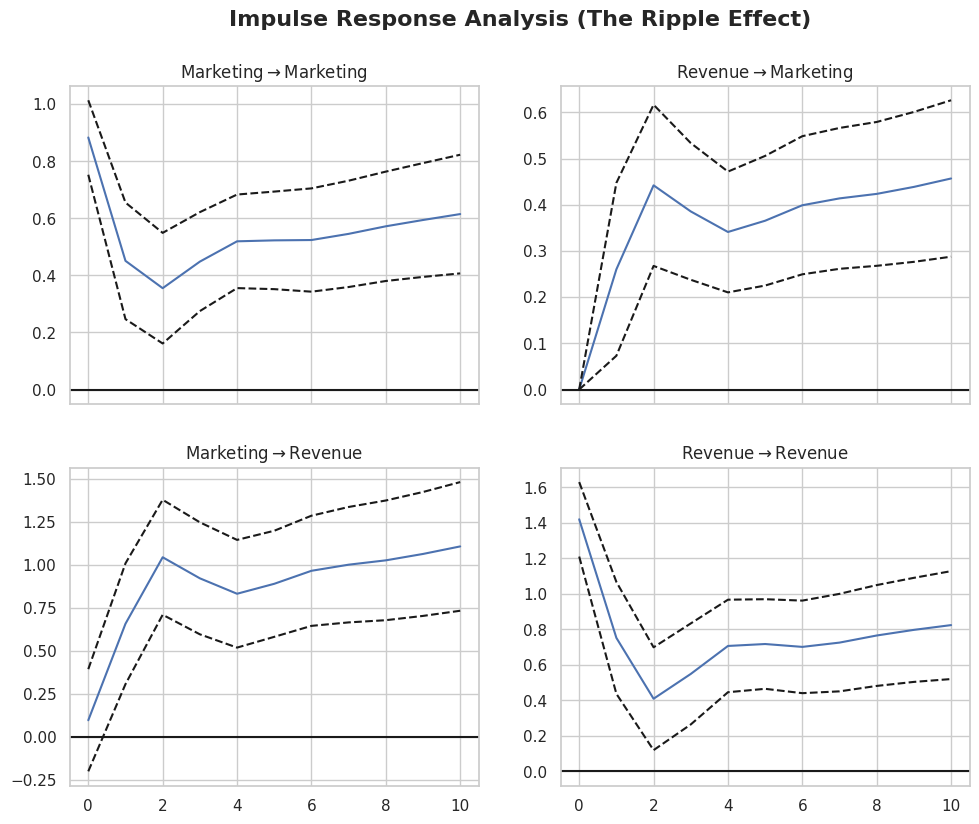

In [3]:
# Generate and plot the Impulse Response Function for 10 time steps
irf = var_fitted.irf(10)

# Plotting the Orthogonalized IRF
fig = irf.plot(orth=True, figsize=(10, 8))
fig.suptitle("Impulse Response Analysis (The Ripple Effect)", fontsize=16, fontweight='bold', y=1.02)
plt.show()

*(Insight: When you run an IRF on enterprise data, it acts as a strategic simulator. You can show the CFO exactly how a $\$1,000,000$ shock to the Advertising budget today will propagate through the Web Traffic, Conversion Rate, and Revenue metrics over the next 10 months, watching the ripples slowly decay back to zero!)*

## Real-World Use Case or Analogy:

Think of Univariate vs. VAR like modeling **Animals in a Forest**:

* **Univariate (ARIMA)**: You are tracking the Rabbit population. You notice that if there are lots of rabbits this year, there will likely be lots of rabbits next year (Autoregression). You build an isolated forecast.
* **Exogenous (SARIMAX)**: You add "Rainfall" as an external feature. High rain means more grass, which means more rabbits. Rainfall impacts rabbits, but rabbits do *not* impact the rain.
* **Multivariate (VAR)**: You realize you are sharing the forest with Foxes.
* If there are many Rabbits $\rightarrow$ Foxes eat well, and the Fox population explodes (Lagged effect).
* If the Fox population explodes $\rightarrow$ They eat all the Rabbits, causing the Rabbit population to crash (Lagged cross-effect).
* If Rabbits crash $\rightarrow$ Foxes starve, Fox population crashes.
* If Foxes crash $\rightarrow$ Rabbits are safe, Rabbit population explodes.



This is a perfect **Endogenous System**. You absolutely cannot predict the future of the rabbits without simultaneously calculating the future of the foxes. They must be solved together as a unified system of equations!